# Imports

## Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
from torch.utils.tensorboard import SummaryWriter 
import json
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from sklearn.manifold import spectral_embedding
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import rbf_kernel

## Import Dataset Classes

In [2]:
from dataset_classes import ISO_NE, ISO_NE_Small, AT, BD_Dataset, NCENT_Dataset, SH_Dataset, PL_Dataset, TN_Dataset

## Import Models

In [3]:
from models_with_temporal_graph import GLFN_TC_Attention, GLFN_TC_GlobalLocal, GLFN_TC_GraphGRU, GLFN_TC_Linear, GLFN_TC_MultiScale

## Import Training and Testing Loops

In [4]:
from helper_functions_trial import train_model, test_model

# Main Function

## ISO_NE

### Linear

In [ ]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = ISO_NE(
        csv_path="GLFN-TC\Datasets\ISO-NE\ISO-NE\selected_data_ISONE.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Linear(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "ISO_NE_GLFN_TC_Linear"
    
    log_dir = f"Final_Metrics_with_raw_data/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on ISO-NE dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

Loaded dataset with 10 features (target=demand), total rows=103776
Raw data length: 103776
Scaler 'train_size' (raw rows): 62265
Scaler 'val_end' (raw rows): 83020
Total valid samples: 103464
Train samples: 62193, Val samples: 20755, Test samples: 20516

🚚 DataLoaders ready. Train batches: 972, Val batches: 325, Test batches: 321

🚀 Training GLFN-TC model on ISO-NE dataset...


c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/100: 100%|██████████| 972/972 [00:14<00:00, 65.66it/s, batch_loss=0.129]


Epoch 001 | Train Loss: 0.6916 | Val Loss: 0.3771 | LR: 0.000100
✅ New best model saved (Val Loss: 0.377135)


Epoch 2/100: 100%|██████████| 972/972 [00:12<00:00, 75.34it/s, batch_loss=0.0845]


Epoch 002 | Train Loss: 0.3172 | Val Loss: 0.3357 | LR: 0.000100
✅ New best model saved (Val Loss: 0.335657)


...

Epoch 069 | Train Loss: 0.1777 | Val Loss: 0.2036 | LR: 0.000001
⚠️  No improvement for 9 epoch(s)


Epoch 70/100: 100%|██████████| 972/972 [00:12<00:00, 78.89it/s, batch_loss=0.0441]


Epoch 070 | Train Loss: 0.1778 | Val Loss: 0.2036 | LR: 0.000001
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/ISO_NE_GLFN_TC_Linear_best_model.pth (Val Loss: 0.203567)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 321/321 [00:01<00:00, 252.96it/s]



Test Results:
MSE = 0.1806 | MAE = 0.3072 | R² = 0.8029

Test metrics logged to TensorBoard.


### Attention

In [ ]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = ISO_NE(
        csv_path="GLFN-TC\Datasets\ISO-NE\ISO-NE\selected_data_ISONE.csv",
        T_in=72,
        T_out=240,
    )


    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_Attention(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "ISO_NE_GLFN_TC_Attention"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on ISO-NE dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 10 features (target=demand), total rows=103776
Raw data length: 103776
Scaler 'train_size' (raw rows): 62265
Scaler 'val_end' (raw rows): 83020
Total valid samples: 103464
Train samples: 62193, Val samples: 20755, Test samples: 20516

🚚 DataLoaders ready. Train batches: 972, Val batches: 325, Test batches: 321

🚀 Training GLFN-TC model on ISO-NE dataset...


Epoch 1/100: 100%|██████████| 972/972 [00:12<00:00, 77.18it/s, batch_loss=0.114]


Epoch 001 | Train Loss: 1.5671 | Val Loss: 0.3650 | LR: 0.000100
✅ New best model saved (Val Loss: 0.365002)


Epoch 2/100: 100%|██████████| 972/972 [00:12<00:00, 77.96it/s, batch_loss=0.0821]


...

Epoch 078 | Train Loss: 0.1735 | Val Loss: 0.1943 | LR: 0.000001
⚠️  No improvement for 9 epoch(s)


Epoch 79/100: 100%|██████████| 972/972 [00:12<00:00, 75.86it/s, batch_loss=0.0381]


Epoch 079 | Train Loss: 0.1739 | Val Loss: 0.1944 | LR: 0.000001
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

Loading best model from Final_Run/ISO_NE_GLFN_TC_Attention_best_model.pth (Val Loss: 0.194341)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 321/321 [00:01<00:00, 245.03it/s]



Test Results:
MSE = 0.1713 | MAE = 0.2955 | R² = 0.8130

Test metrics logged to TensorBoard.


### GlobalLocal

In [ ]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = ISO_NE(
    csv_path="GLFN-TC\Datasets\ISO-NE\ISO-NE\selected_data_ISONE.csv",
    T_in=72,
    T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_GlobalLocal(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "ISO_NE_GLFN_TC_GlobalLocal"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on ISO-NE dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loaded dataset with 10 features (target=demand), total rows=103776
Raw data length: 103776
Scaler 'train_size' (raw rows): 62265
Scaler 'val_end' (raw rows): 83020
Total valid samples: 103464
Train samples: 62193, Val samples: 20755, Test samples: 20516

🚚 DataLoaders ready. Train batches: 972, Val batches: 325, Test batches: 321

🚀 Training GLFN-TC model on ISO-NE dataset...


Epoch 1/100: 100%|██████████| 972/972 [00:13<00:00, 74.22it/s, batch_loss=0.0991]


Epoch 001 | Train Loss: 6.6448 | Val Loss: 0.3407 | LR: 0.000100
✅ New best model saved (Val Loss: 0.340741)


Epoch 2/100: 100%|██████████| 972/972 [00:12<00:00, 75.21it/s, batch_loss=0.0767]


...

Epoch 099 | Train Loss: 0.1678 | Val Loss: 0.1919 | LR: 0.000001
⚠️  No improvement for 9 epoch(s)


Epoch 100/100: 100%|██████████| 972/972 [00:12<00:00, 76.07it/s, batch_loss=0.0317]


Epoch 100 | Train Loss: 0.1679 | Val Loss: 0.1918 | LR: 0.000001
✅ New best model saved (Val Loss: 0.191836)

Loading best model from Final_Run/ISO_NE_GLFN_TC_GlobalLocal_best_model.pth (Val Loss: 0.191836)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 321/321 [00:01<00:00, 243.96it/s]



Test Results:
MSE = 0.1698 | MAE = 0.2947 | R² = 0.8147

Test metrics logged to TensorBoard.


### Multi-Scale

In [5]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = ISO_NE(
        csv_path="GLFN-TC\Datasets\ISO-NE\ISO-NE\selected_data_ISONE.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    
    print("\n🔍 Generating Feature Clusters...")

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform
    
    

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = GLFN_TC_MultiScale(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "ISO_NE_GLFN_TC_MultiScale_Temporal_Graph_Learning"
    
    log_dir = f"CSE498R_Supervisor_Fixes/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on ISO-NE dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Paper_Runs/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

Loaded dataset with 19 features (target=demand), total rows=103608
Raw data length: 103608
Scaler 'train_size' (raw rows): 62164
Scaler 'val_end' (raw rows): 82886

🔍 Generating Feature Clusters...
Total valid samples: 103296
Train samples: 62092, Val samples: 20722, Test samples: 20482

🚚 DataLoaders ready. Train batches: 971, Val batches: 324, Test batches: 321

🚀 Training GLFN-TC model on ISO-NE dataset...


c:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\load_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/100: 100%|██████████| 971/971 [00:22<00:00, 42.97it/s, batch_loss=0.125] 


Epoch 001 | Train Loss: 0.4515 | Val Loss: 0.2794 | LR: 0.000100
✅ New best model saved (Val Loss: 0.279417)


Epoch 2/100: 100%|██████████| 971/971 [00:21<00:00, 44.41it/s, batch_loss=0.0854]


Epoch 002 | Train Loss: 0.2463 | Val Loss: 0.2341 | LR: 0.000100
✅ New best model saved (Val Loss: 0.234091)


...

Epoch 080 | Train Loss: 0.1459 | Val Loss: 0.1796 | LR: 0.000001
⚠️  No improvement for 9 epoch(s)


Epoch 81/100: 100%|██████████| 971/971 [00:19<00:00, 48.62it/s, batch_loss=0.0296]


Epoch 081 | Train Loss: 0.1459 | Val Loss: 0.1796 | LR: 0.000001
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

               TIMING REPORT               
⏱️  Time to reach Best Model: 28m 0s
⏱️  Total Training Duration:  31m 42s

Loading best model from Paper_Runs/ISO_NE_GLFN_TC_MultiScale_Temporal_Graph_Learning_best_model.pth (Val Loss: 0.179219)
Training complete. TensorBoard logs saved.

🧪 Testing model performance...



Testing: 100%|██████████| 321/321 [00:02<00:00, 145.79it/s]



Test Results:
MSE = 0.1629 | MAE = 0.2873 | R² = 0.8219

Test metrics logged to TensorBoard.


Using device: cuda
Loaded dataset with 19 features (target=demand), total rows=103608
Fitting scaler on training data...
Test samples: 20482
✅ Model weights loaded successfully.
Running inference...


100%|██████████| 321/321 [00:02<00:00, 122.11it/s]



Inverse transforming data...

      REAL-WORLD METRICS (Original Scale)
MSE:  1357535.5497
RMSE: 1165.1333
MAE:  829.3911
R²:   0.8219

Plot saved to MultiScale_Forecast_Plot.png


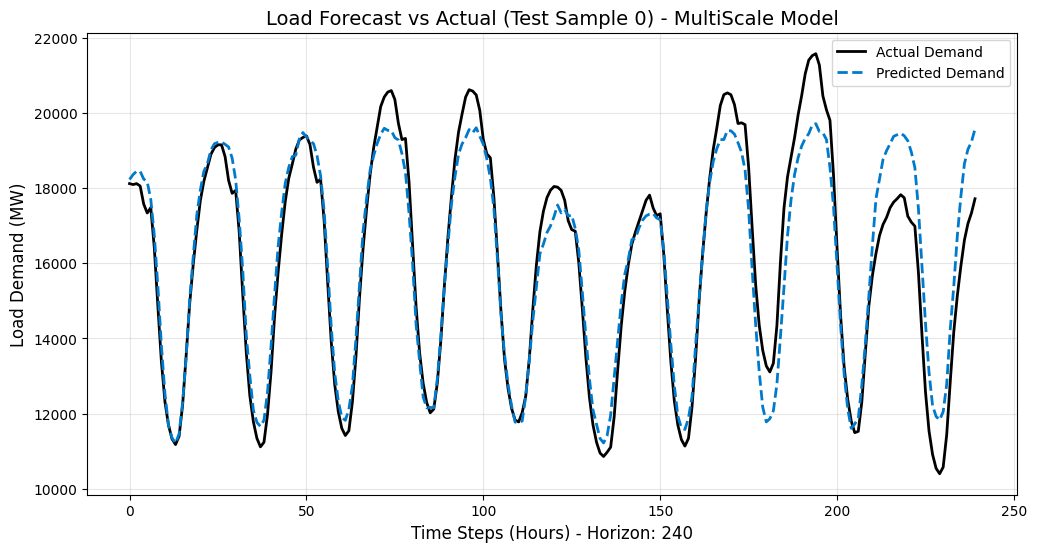

: 

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import json

# Import your custom classes
from dataset_classes import AT
from models_with_temporal_graph import GLFN_TC_MultiScale

def inverse_transform_targets(preds_scaled, trues_scaled, scaler, target_idx=0):
    """
    Manually inverse transforms the target variable using the scaler's 
    stored mean and scale (std) for the specific target column.
    """
    # Get the specific mean and std for the target column
    target_mean = scaler.mean_[target_idx]
    target_scale = scaler.scale_[target_idx]
    
    # Apply inverse transformation: x_original = x_scaled * std + mean
    preds_orig = preds_scaled * target_scale + target_mean
    trues_orig = trues_scaled * target_scale + target_mean
    
    return preds_orig, trues_orig

def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # --- 1. Load Dataset ---
    dataset = ISO_NE(
        csv_path="GLFN-TC\Datasets\ISO-NE\ISO-NE\selected_data_ISONE.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )

    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)

    # --- 2. Re-fit the Scaler ---
    print("Fitting scaler on training data...")
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    
    # Apply scaler to dataset
    dataset.apply_scaler(scaler)
    
    # --- CRITICAL FIX: Manually store the scaler in the dataset object ---
    dataset.scaler = scaler 
    
    # Define Test Indices
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    effective_len = len(dataset)
    val_end = min(val_end, effective_len) 
    
    test_idx = range(val_end, effective_len)
    test_subset = Subset(dataset, test_idx)
    
    test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)
    print(f"Test samples: {len(test_idx)}")

    # --- 3. Load Model ---
    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
    }
    
    model = GLFN_TC_MultiScale(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
        dropout_forecast=hparams["dropout_forecast"]
    ).to(device)

    weight_path = "Paper_Runs/ISO_NE_GLFN_TC_MultiScale_Temporal_Graph_Learning_best_model.pth"
    
    try:
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print("✅ Model weights loaded successfully.")
    except FileNotFoundError:
        print(f"❌ Error: Could not find model file at {weight_path}")
        return

    # --- 4. Run Inference ---
    model.eval()
    preds_list = []
    trues_list = []

    print("Running inference...")
    with torch.no_grad():
        for X, Y in tqdm(test_loader):
            X = X.to(device)
            Y = Y.to(device)
            
            # The MultiScale model returns (prediction, adjacency)
            out, _ = model(X) 
            
            preds_list.append(out.cpu().numpy())
            trues_list.append(Y.cpu().numpy())

    # Concatenate all batches
    preds_scaled = np.concatenate(preds_list, axis=0)
    trues_scaled = np.concatenate(trues_list, axis=0)

    # --- 5. Inverse Transform ---
    print("\nInverse transforming data...")
    # Now dataset.scaler exists because we assigned it in Step 2
    preds_orig, trues_orig = inverse_transform_targets(
        preds_scaled, 
        trues_scaled, 
        dataset.scaler, 
        target_idx=dataset.target_idx 
    )

    # --- 6. Calculate Metrics (Original Scale) ---
    mse = mean_squared_error(trues_orig, preds_orig)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(trues_orig, preds_orig)
    r2 = r2_score(trues_orig, preds_orig)

    print("\n" + "="*40)
    print("      REAL-WORLD METRICS (Original Scale)")
    print("="*40)
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")
    print("="*40)

    # --- 7. Plotting ---
    sample_idx = 0 
    
    plt.figure(figsize=(12, 6))
    plt.plot(trues_orig[sample_idx], label='Actual Demand', color='black', linewidth=2)
    plt.plot(preds_orig[sample_idx], label='Predicted Demand', color='#007acc', linestyle='--', linewidth=2)
    
    plt.title(f"Load Forecast vs Actual (Test Sample {sample_idx}) - MultiScale Model", fontsize=14)
    plt.xlabel(f"Time Steps (Hours) - Horizon: {hparams['T_out']}", fontsize=12)
    plt.ylabel("Load Demand (MW)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    save_img_path = "MultiScale_Forecast_Plot.png"
    plt.savefig(save_img_path, dpi=300)
    print(f"\nPlot saved to {save_img_path}")
    plt.show()

if __name__ == "__main__":
    main()

Using device: cuda
Loaded dataset with 19 features (target=demand), total rows=103608
Fitting scaler on training data...

🎲 Randomly selecting 64 samples from the unseen data pool...
   Pool size: 41132 potential windows
✅ Model weights loaded successfully.
Running inference...


100%|██████████| 1/1 [00:00<00:00, 26.32it/s]


      REAL-WORLD METRICS (Original Scale)
MSE:  1096751.8819
RMSE: 1047.2592
MAE:  758.2688
MAPE: 5.1393%
R²:   0.8593



Plot saved to Random_Forecast_Idx_88644.png


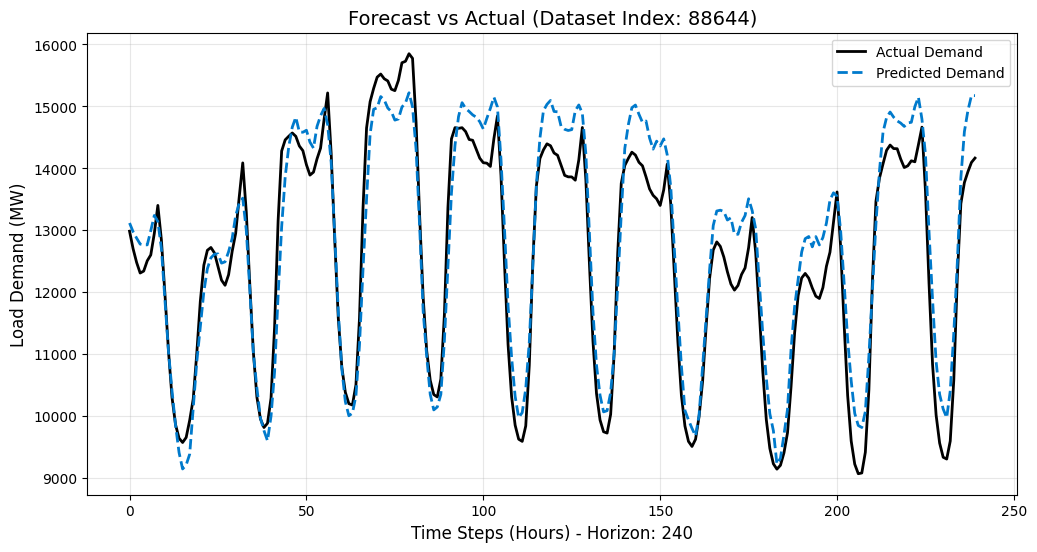

In [9]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import json

# Import your custom classes
from dataset_classes import AT
from models_with_temporal_graph import GLFN_TC_MultiScale

# --- Helper Function for Inverse Transform ---
def inverse_transform_targets(preds_scaled, trues_scaled, scaler, target_idx=0):
    target_mean = scaler.mean_[target_idx]
    target_scale = scaler.scale_[target_idx]
    preds_orig = preds_scaled * target_scale + target_mean
    trues_orig = trues_scaled * target_scale + target_mean
    return preds_orig, trues_orig

def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # --- 1. Load Dataset ---
    dataset = ISO_NE(
        csv_path="GLFN-TC\Datasets\ISO-NE\ISO-NE\selected_data_ISONE.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )

    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    
    # --- 2. Re-fit the Scaler (Crucial: Fit on Train, Apply to All) ---
    print("Fitting scaler on training data...")
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler 

    # ---------------------------------------------------------
    # --- MODIFIED SECTION: RANDOMIZED TEST SAMPLING ---
    # ---------------------------------------------------------
    
    # Define the "Pool" of data we are allowed to test on
    # (e.g., everything after the training set)
    valid_test_start = train_split_idx
    valid_test_end = len(dataset) # The dataset class handles bounds internally usually
    
    # Create a list of all possible indices in the unseen portion
    possible_indices = np.arange(valid_test_start, valid_test_end)
    
    # How many samples do you want to test this time?
    NUM_TEST_SAMPLES = 64  
    
    print(f"\n🎲 Randomly selecting {NUM_TEST_SAMPLES} samples from the unseen data pool...")
    print(f"   Pool size: {len(possible_indices)} potential windows")

    # Pick random indices (replace=False ensures no duplicates in this batch)
    random_test_idx = np.random.choice(possible_indices, size=NUM_TEST_SAMPLES, replace=False)
    
    # Sort them just so the progress bar makes chronological sense (optional)
    random_test_idx.sort()

    # Create the Subset with these RANDOM indices
    test_subset = Subset(dataset, random_test_idx)
    test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)
    
    # ---------------------------------------------------------
    # ---------------------------------------------------------

    # --- 3. Load Model ---
    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
    }
    
    model = GLFN_TC_MultiScale(**hparams).to(device) # unpacking dict for cleaner code

    weight_path = "Paper_Runs/ISO_NE_GLFN_TC_MultiScale_Temporal_Graph_Learning_best_model.pth"
    
    try:
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print("✅ Model weights loaded successfully.")
    except FileNotFoundError:
        print(f"❌ Error: Could not find model file at {weight_path}")
        return

    # --- 4. Run Inference ---
    model.eval()
    preds_list = []
    trues_list = []
    inputs_list = [] # Store inputs if you want to verify randomness

    print("Running inference...")
    with torch.no_grad():
        for X, Y in tqdm(test_loader):
            X = X.to(device)
            Y = Y.to(device)
            
            out, _ = model(X) 
            
            preds_list.append(out.cpu().numpy())
            trues_list.append(Y.cpu().numpy())

    preds_scaled = np.concatenate(preds_list, axis=0)
    trues_scaled = np.concatenate(trues_list, axis=0)

    # --- 5. Inverse Transform ---
    # CAUTION: Ensure dataset.target_idx is defined in your AT class, otherwise use 0
    target_idx = getattr(dataset, 'target_idx', 0) 
    
    preds_orig, trues_orig = inverse_transform_targets(
        preds_scaled, trues_scaled, dataset.scaler, target_idx=target_idx
    )

# --- 6. Calculate Metrics (Original Scale) ---
    mse = mean_squared_error(trues_orig, preds_orig)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(trues_orig, preds_orig)
    r2 = r2_score(trues_orig, preds_orig)
    
    # --- NEW: Calculate MAPE ---
    # We add a tiny epsilon (1e-10) to avoid division by zero if a target is 0
    epsilon = 1e-10 
    mape = np.mean(np.abs((trues_orig - preds_orig) / (trues_orig + epsilon))) * 100

    print("\n" + "="*40)
    print("      REAL-WORLD METRICS (Original Scale)")
    print("="*40)
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}%")  # <--- Added MAPE here
    print(f"R²:   {r2:.4f}")
    print("="*40)

    # --- 7. Plotting a Random Sample from this Batch ---
    # Pick one random sample from the batch we just generated
    sample_idx = np.random.randint(0, len(preds_orig))
    
    plt.figure(figsize=(12, 6))
    plt.plot(trues_orig[sample_idx], label='Actual Demand', color='black', linewidth=2)
    plt.plot(preds_orig[sample_idx], label='Predicted Demand', color='#007acc', linestyle='--', linewidth=2)
    
    # Add title with the specific index used so you can track it
    actual_dataset_idx = random_test_idx[sample_idx]
    plt.title(f"Forecast vs Actual (Dataset Index: {actual_dataset_idx})", fontsize=14)
    plt.xlabel(f"Time Steps (Hours) - Horizon: {hparams['T_out']}", fontsize=12)
    plt.ylabel("Load Demand (MW)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    save_img_path = f"Random_Forecast_Idx_{actual_dataset_idx}.png"
    plt.savefig(save_img_path, dpi=300)
    print(f"\nPlot saved to {save_img_path}")
    plt.show()

if __name__ == "__main__":
    main()

Using device: cpu
Loaded dataset with 19 features (target=demand), total rows=103608
Fitting scaler on training data...

🎲 Randomly selecting 64 samples...
✅ Model weights loaded successfully.
Running inference...


100%|██████████| 1/1 [00:00<00:00, 29.41it/s]


RMSE: 1022.5443 | MAPE: 4.9932%

🧠 Running Manual Integrated Gradients for Step +240...


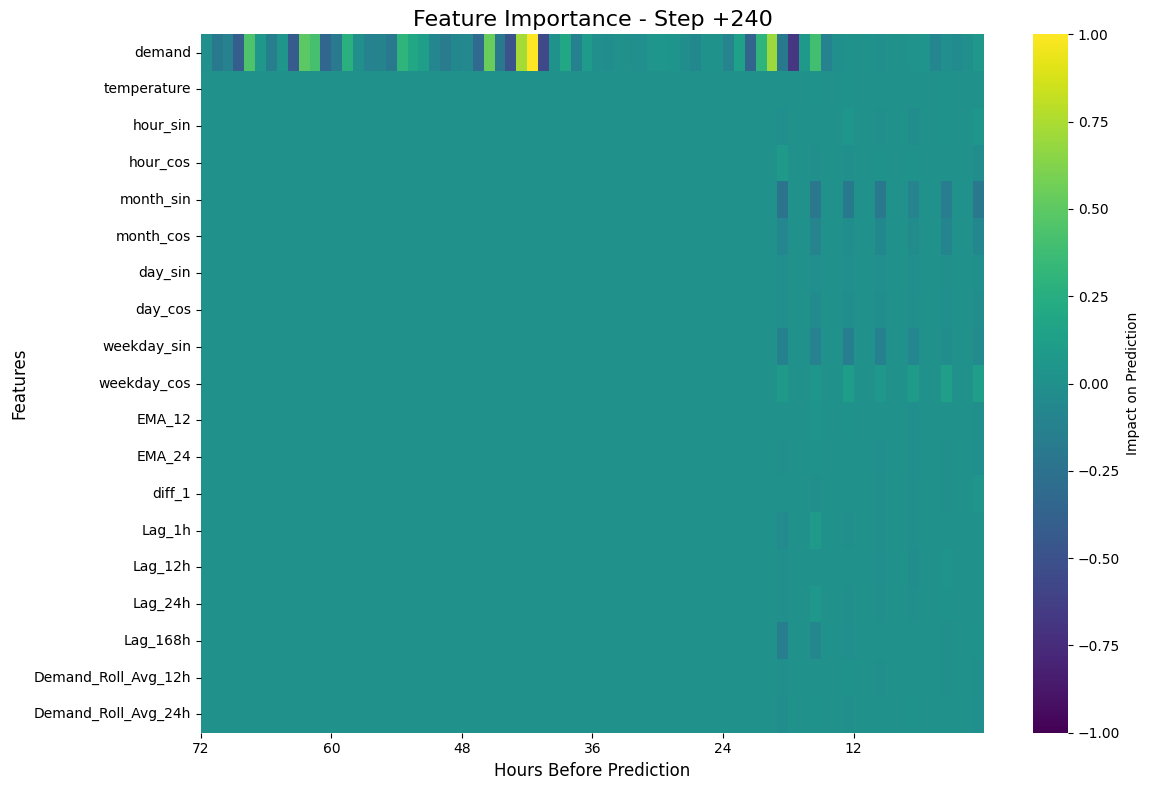

In [11]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import json

# Import your custom classes
from dataset_classes import ISO_NE
from models_with_temporal_graph import GLFN_TC_MultiScale

# ---------------------------------------------------------
# --- 1. MANUAL INTEGRATED GRADIENTS (NO CAPTUM) ---
# ---------------------------------------------------------
def manual_integrated_gradients(model, input_tensor, target_step=0, steps=50, device='cuda'):
    """
    Computes Integrated Gradients manually without Captum.
    Math: (Input - Baseline) * Integral(Gradients)
    """
    model.eval()
    
    # 1. Define Baseline (Zero tensor)
    baseline = torch.zeros_like(input_tensor).to(device)
    
    # 2. Generate path inputs (Interpolation between Baseline and Input)
    # Shape: (steps+1, N, T_in)
    alphas = torch.linspace(0, 1, steps + 1).to(device)
    alphas = alphas.view(-1, 1, 1) # Reshape for broadcasting
    
    # interpolated_inputs: Batch of size (steps+1)
    # We expand input_tensor to match the batch size
    input_expanded = input_tensor.expand(steps + 1, -1, -1)
    baseline_expanded = baseline.expand(steps + 1, -1, -1)
    
    interpolated_inputs = baseline_expanded + alphas * (input_expanded - baseline_expanded)
    interpolated_inputs.requires_grad = True

    # 3. Forward Pass
    # We pass all 'steps' as a single batch for speed
    preds, _ = model(interpolated_inputs) # output: (steps+1, T_out)
    
    # 4. Select the specific time-step we want to explain
    target_score = preds[:, target_step].sum()
    
    # 5. Backward Pass (Compute Gradients)
    grads = torch.autograd.grad(
        outputs=target_score,
        inputs=interpolated_inputs,
        create_graph=False,
        retain_graph=False
    )[0] # Shape: (steps+1, N, T_in)
    
    # 6. Approximate Integral (Trapezoidal Rule or Average)
    # We average the gradients across all steps
    avg_grads = torch.mean(grads, dim=0) # Shape: (N, T_in)
    
    # 7. Calculate IG: (Input - Baseline) * Avg_Gradients
    delta = input_tensor[0] - baseline[0] # Remove batch dim 1
    ig = delta * avg_grads
    
    return ig.cpu().detach().numpy()

# ---------------------------------------------------------
# --- HELPER FUNCTIONS ---
# ---------------------------------------------------------
def inverse_transform_targets(preds_scaled, trues_scaled, scaler, target_idx=0):
    target_mean = scaler.mean_[target_idx]
    target_scale = scaler.scale_[target_idx]
    preds_orig = preds_scaled * target_scale + target_mean
    trues_orig = trues_scaled * target_scale + target_mean
    return preds_orig, trues_orig

def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # --- 1. Load Dataset ---
    dataset = ISO_NE(
        csv_path="GLFN-TC\Datasets\ISO-NE\ISO-NE\selected_data_ISONE.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )
    
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    
    # --- 2. Re-fit Scaler ---
    print("Fitting scaler on training data...")
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler 

    # --- 3. Random Sampling ---
    valid_test_start = train_split_idx
    possible_indices = np.arange(valid_test_start, len(dataset))
    
    NUM_TEST_SAMPLES = 64  
    print(f"\n🎲 Randomly selecting {NUM_TEST_SAMPLES} samples...")
    random_test_idx = np.random.choice(possible_indices, size=NUM_TEST_SAMPLES, replace=False)
    random_test_idx.sort()

    test_subset = Subset(dataset, random_test_idx)
    test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)
    
    # --- 4. Load Model ---
    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
    }
    
    model = GLFN_TC_MultiScale(**hparams).to(device)

    weight_path = "Paper_Runs/ISO_NE_GLFN_TC_MultiScale_Temporal_Graph_Learning_best_model.pth"
    try:
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print("✅ Model weights loaded successfully.")
    except FileNotFoundError:
        print(f"❌ Error: Could not find model file at {weight_path}")
        return

    # --- 5. Inference ---
    model.eval()
    preds_list = []
    trues_list = []
    xai_input_tensor = None 

    print("Running inference...")
    with torch.no_grad():
        for i, (X, Y) in enumerate(tqdm(test_loader)):
            X = X.to(device)
            Y = Y.to(device)
            
            # Save the first sample for XAI
            if i == 0:
                xai_input_tensor = X[0:1].clone() # Keep on device, requires_grad handles inside func

            out, _ = model(X) 
            preds_list.append(out.cpu().numpy())
            trues_list.append(Y.cpu().numpy())

    preds_scaled = np.concatenate(preds_list, axis=0)
    trues_scaled = np.concatenate(trues_list, axis=0)
    
    # Inverse Transform & Metrics (Skipped for brevity, same as before)
    target_idx = getattr(dataset, 'target_idx', 0) 
    preds_orig, trues_orig = inverse_transform_targets(preds_scaled, trues_scaled, dataset.scaler, target_idx)
    
    mse = mean_squared_error(trues_orig, preds_orig)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((trues_orig - preds_orig) / (trues_orig + 1e-10))) * 100
    
    print(f"\nRMSE: {rmse:.4f} | MAPE: {mape:.4f}%")

    # ---------------------------------------------------------
    # --- 6. XAI: PLOT MANUAL INTEGRATED GRADIENTS ---
    # ---------------------------------------------------------
    if xai_input_tensor is not None:
        target_step = 239 # Predict next hour
        print(f"\n🧠 Running Manual Integrated Gradients for Step +{target_step+1}...")
        
        # Call our manual function
        attr_matrix = manual_integrated_gradients(
            model, 
            xai_input_tensor, 
            target_step=target_step, 
            steps=50, 
            device=device
        )
        
        # Normalize for cleaner plot (-1 to 1)
        attr_matrix = attr_matrix / (np.max(np.abs(attr_matrix)) + 1e-9)

        # Plot
        plt.figure(figsize=(12, 8))
        sns.heatmap(
            attr_matrix, 
            yticklabels=dataset.feature_names, 
            # --- COLOR CHANGE HERE ---
            # Options: 'coolwarm' (Blue-Red), 'viridis' (Purple-Yellow), 'magma' (Black-Pink)
            cmap="viridis",  
            center=0,
            vmin = -1, vmax=1,
            cbar_kws={'label': 'Impact on Prediction'}
        )
        
        T_in = attr_matrix.shape[1]
        plt.title(f"Feature Importance - Step +{target_step+1}", fontsize=16)
        
        # X-axis formatting
        plt.xticks(
            ticks=np.arange(0, T_in, 12),
            labels=np.arange(T_in, 0, -12)
        )
        plt.xlabel("Hours Before Prediction", fontsize=12)
        plt.ylabel("Features", fontsize=12)
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()

Using device: cpu
Loaded dataset with 19 features (target=demand), total rows=103608
✅ Model loaded.
🚀 Training PGExplainer for 15 epochs...
   Epoch 1/15 | Loss: 39.4425
   Epoch 2/15 | Loss: 6.7800
   Epoch 3/15 | Loss: 1.3243
   Epoch 4/15 | Loss: 0.4694
   Epoch 5/15 | Loss: 0.2453
   Epoch 6/15 | Loss: 0.1656
   Epoch 7/15 | Loss: 0.1437
   Epoch 8/15 | Loss: 0.1407
   Epoch 9/15 | Loss: 0.1267
   Epoch 10/15 | Loss: 0.1076
   Epoch 11/15 | Loss: 0.1000
   Epoch 12/15 | Loss: 0.0969
   Epoch 13/15 | Loss: 0.0959
   Epoch 14/15 | Loss: 0.1132
   Epoch 15/15 | Loss: 0.0893

🧠 Generating Explanations...


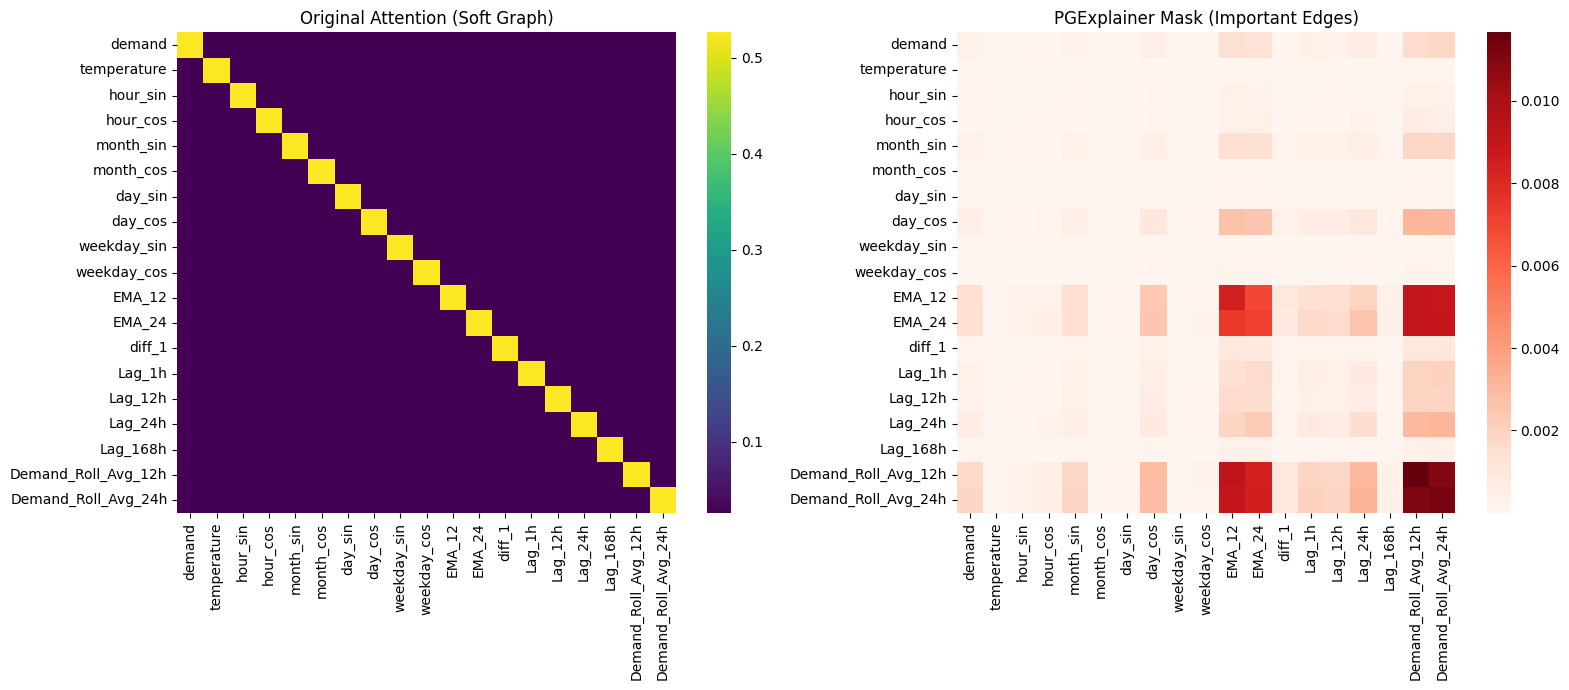


✅ Interpretation:
The LEFT plot is what your model 'thinks' (Attention weights).
The RIGHT plot is what PGExplainer 'selected' as strictly necessary.
If an edge is bright Red in the right plot, removing it would destroy the forecast.


: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# Import your custom classes
from dataset_classes import ISO_NE
from models_with_temporal_graph import GLFN_TC_MultiScale

# ---------------------------------------------------------
# --- 1. DEFINE THE PG-EXPLAINER MODULE ---
# ---------------------------------------------------------
class DensePGExplainer(nn.Module):
    """
    Adapts the PGExplainer algorithm for Dense, Temporal Graphs.
    Trains a mask generator to select important edges in the NxN adjacency matrix.
    """
    def __init__(self, model, hidden_dim=64):
        super().__init__()
        self.model = model
        self.model.eval() # The original model must be frozen
        
        # The Explainer Network
        # Input: 2 * hidden_dim (concatenation of node pair embeddings)
        # Output: 1 (The probability of keeping the edge)
        self.explainer_net = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
    def _create_explainer_input(self, H):
        """
        Constructs pair-wise embeddings for the dense graph.
        H: (Batch, N, D)
        Returns: (Batch, N, N, 2*D)
        """
        B, N, D = H.shape
        # Repeat H to form pairs
        # H_i: (B, N, 1, D) -> repeated to (B, N, N, D)
        # H_j: (B, 1, N, D) -> repeated to (B, N, N, D)
        H_i = H.unsqueeze(2).repeat(1, 1, N, 1)
        H_j = H.unsqueeze(1).repeat(1, N, 1, 1)
        
        # Concatenate to get (h_i || h_j) for every pair
        pair_embeds = torch.cat([H_i, H_j], dim=-1)
        return pair_embeds

    def forward(self, X, temperature=0.1):
        """
        Forward pass that generates a mask and runs the model with it.
        """
        # 1. Get original embeddings from the frozen model
        with torch.no_grad():
            H_temp = self.model.temporal_conv(X) # (B, N, D)
            A_orig = self.model.graph_learn(H_temp) # (B, N, N)
        
        # 2. Predict the Mask using the Explainer Network
        pair_embeds = self._create_explainer_input(H_temp) # (B, N, N, 2D)
        
        # Predict logits for every edge
        mask_logits = self.explainer_net(pair_embeds).squeeze(-1) # (B, N, N)
        
        # 3. Sampling (Reparameterization Trick)
        # We use Concrete Distribution (Gumbel-Sigmoid) to make it differentiable
        # During training, we sample. During inference, we just use sigmoid.
        if self.training:
            eps = (torch.rand_like(mask_logits) + 1e-8).log()
            eps = (torch.rand_like(mask_logits) + 1e-8).log() - eps
            mask = torch.sigmoid((mask_logits + eps) / temperature)
        else:
            mask = torch.sigmoid(mask_logits)
            
        # 4. Apply Mask to Original Graph
        # We perform element-wise multiplication
        A_masked = A_orig * mask
        
        # 5. Run the rest of the model with the MASKED graph
        # Note: We must allow gradients to flow back to the Mask, but NOT the model weights
        # So we detach model weights implicitly by not adding them to the optimizer later.
        H_gcn = self.model.dense_gcn(H_temp, A_masked)
        Y_hat_masked = self.model.forecaster(X, H_gcn)
        
        return Y_hat_masked, mask, A_orig

def train_pg_explainer(explainer, dataset, device, epochs=10, lr=0.005, lambda_size=0.05):
    """
    Trains the explainer to minimize prediction error while maximizing sparsity.
    """
    optimizer = optim.Adam(explainer.explainer_net.parameters(), lr=lr)
    
    # We use a subset for training the explainer (it learns fast)
    # Train on 200 samples
    subset_idx = range(len(dataset)-300, len(dataset)-100)
    loader = DataLoader(Subset(dataset, subset_idx), batch_size=32, shuffle=True)
    
    print(f"🚀 Training PGExplainer for {epochs} epochs...")
    
    for epoch in range(epochs):
        total_loss = 0
        
        for X, Y in loader:
            X = X.to(device)
            Y = Y.to(device)
            
            # 1. Get Original Prediction (Target)
            with torch.no_grad():
                Y_orig, _ = explainer.model(X)
            
            # 2. Get Masked Prediction
            explainer.train()
            Y_masked, mask, _ = explainer(X)
            
            # 3. Calculate Loss
            # Prediction Fidelity Loss: Masked pred should match Original pred
            loss_pred = nn.MSELoss()(Y_masked, Y_orig)
            
            # Size Loss: Mask should be sparse (sum of mask -> 0)
            loss_size = torch.mean(torch.sum(mask, dim=[-1, -2]))
            
            # Entropy Loss (Optional): Encourage binary (0 or 1) masks
            # loss_ent = -mask * torch.log(mask + 1e-8) - (1 - mask) * torch.log(1 - mask + 1e-8)
            # loss_ent = torch.mean(loss_ent)

            # Total Loss
            loss = loss_pred + lambda_size * loss_size
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
        print(f"   Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")
        
    return explainer

# ---------------------------------------------------------
# --- 2. MAIN SCRIPT ---
# ---------------------------------------------------------
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")
    
    # --- 1. Load Dataset ---
    dataset = ISO_NE(
        csv_path="GLFN-TC\Datasets\ISO-NE\ISO-NE\selected_data_ISONE.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )
    
    # Scaler
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler 

    # Load Model
    hparams = {
        "N": dataset.N, "T_in": 72, "T_out": 240, "d": 32,
        "hidden_dim": 64, "GCN_Layer": 5, "dropout_forecast": 0.1,
        "dropout_gcn": 0.2, "dropout_temporal": 0.2,
    }
    model = GLFN_TC_MultiScale(**hparams).to(device)
    weight_path = "Paper_Runs/ISO_NE_GLFN_TC_MultiScale_Temporal_Graph_Learning_best_model.pth"
    try:
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print("✅ Model loaded.")
    except:
        print("❌ Model not found.")
        return

    # --- Initialize & Train PGExplainer ---
    pg_explainer = DensePGExplainer(model, hidden_dim=64).to(device)
    
    # Train it! (Learns which edges are important)
    pg_explainer = train_pg_explainer(pg_explainer, dataset, device, epochs=15)
    
    # --- Inference & Visualization ---
    print("\n🧠 Generating Explanations...")
    pg_explainer.eval()
    
    # Grab a batch to explain
    test_loader = DataLoader(Subset(dataset, range(len(dataset)-50, len(dataset))), batch_size=32)
    X_test, _ = next(iter(test_loader))
    X_test = X_test.to(device)
    
    with torch.no_grad():
        _, mask, A_orig = pg_explainer(X_test)
        
        # Average the learned mask across the batch
        # This gives us the "Global Importance" learned by the explainer
        avg_mask = mask.mean(dim=0).cpu().numpy()
        avg_orig = A_orig.mean(dim=0).cpu().numpy()
        
    # --- Plotting ---
    plt.figure(figsize=(16, 7))
    
    # Plot 1: Original Learned Graph (Attention)
    plt.subplot(1, 2, 1)
    sns.heatmap(avg_orig, xticklabels=dataset.feature_names, yticklabels=dataset.feature_names, cmap="viridis")
    plt.title("Original Attention (Soft Graph)")
    
    # Plot 2: PGExplainer Result (Hard Mask)
    plt.subplot(1, 2, 2)
    sns.heatmap(avg_mask, xticklabels=dataset.feature_names, yticklabels=dataset.feature_names, cmap="Reds")
    plt.title("PGExplainer Mask (Important Edges)")
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Interpretation:")
    print("The LEFT plot is what your model 'thinks' (Attention weights).")
    print("The RIGHT plot is what PGExplainer 'selected' as strictly necessary.")
    print("If an edge is bright Red in the right plot, removing it would destroy the forecast.")

if __name__ == "__main__":
    main()

# Trend vs Residual and Combination

Using device: cpu
Loading ISO_NE Dataset...
Loaded dataset with 19 features (target=demand), total rows=103608
✅ Model weights loaded successfully.
Analyzing Sample Index: 83745


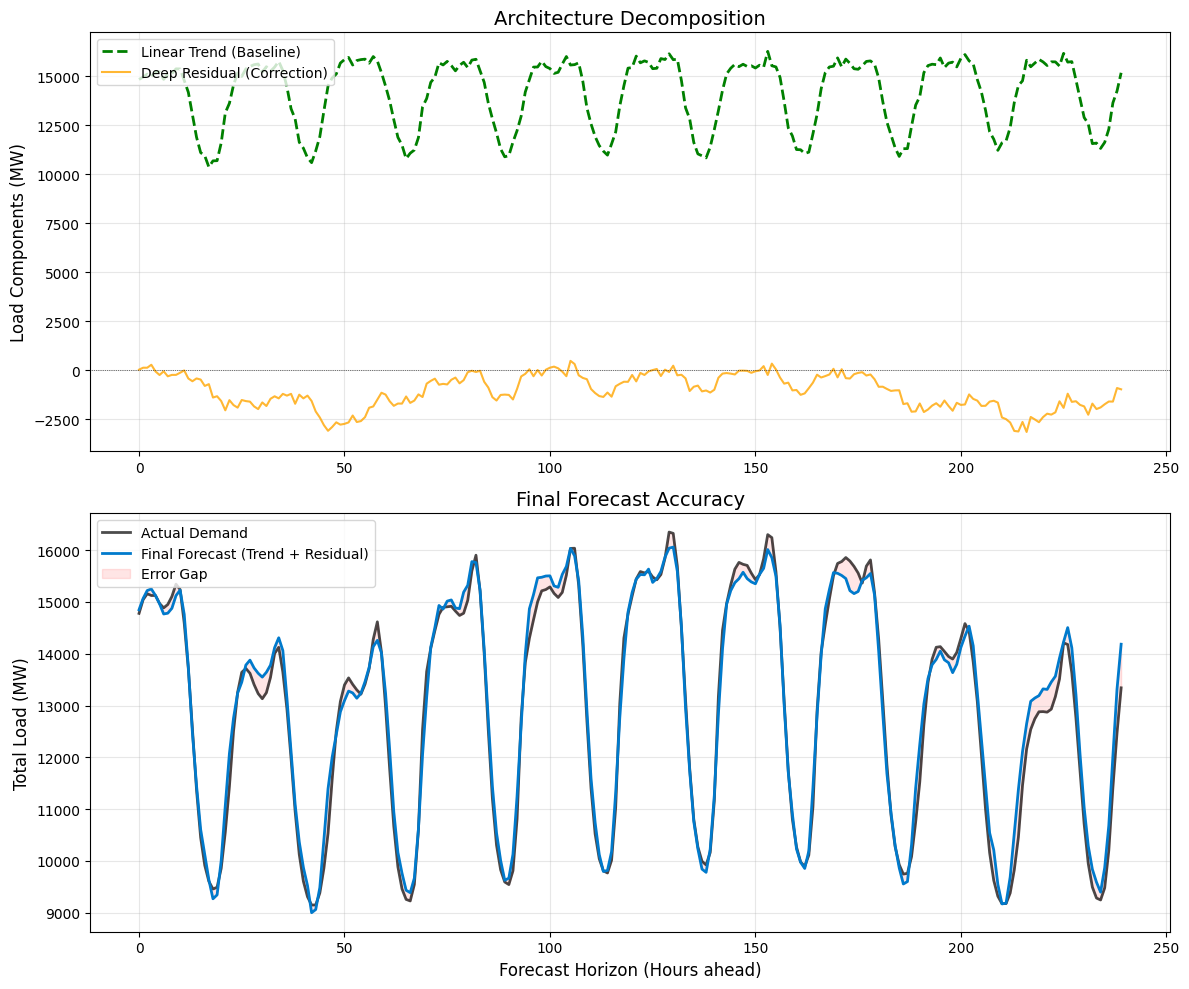

In [7]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# Import your custom classes
from dataset_classes import ISO_NE
from models_with_temporal_graph import GLFN_TC_MultiScale

def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # --- 1. Load Dataset ---
    print("Loading ISO_NE Dataset...")
    dataset = ISO_NE(
        csv_path="Datasets\selected_data_ISONE.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )

    # --- 2. Fit Scaler (Crucial for Inverse Transform) ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler 

    # --- 3. Load Model ---
    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
    }
    
    model = GLFN_TC_MultiScale(**hparams).to(device)
    
    # Update this path to where your best model is saved
    weight_path = "Paper_Runs/ISO_NE_GLFN_TC_MultiScale_Temporal_Graph_Learning_best_model.pth"
    
    try:
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print("✅ Model weights loaded successfully.")
    except FileNotFoundError:
        print(f"❌ Error: Could not find model file at {weight_path}")
        return

    # --- 4. Select a Random Sample from Test Set ---
    valid_test_start = train_split_idx
    # random_idx = np.random.randint(valid_test_start, len(dataset))
    random_idx = 83745
    
    print(f"Analyzing Sample Index: {random_idx}")
    input_tensor, true_target_scaled = dataset[random_idx]
    
    # Add batch dimension
    X = input_tensor.unsqueeze(0).to(device) # (1, N, T_in)
    
    # --- 5. Manual Forward Pass (Decomposition) ---
    model.eval()
    with torch.no_grad():
        # A. Run the Upstream Layers (TCN -> Graph -> GCN)
        H_temp = model.temporal_conv(X)       # (B, N, hidden)
        A = model.graph_learn(H_temp)         # (B, N, N)
        H_gcn = model.dense_gcn(H_temp, A)    # (B, N, hidden)
        
        # B. Run the "Trend" Path (Linear Baseline)
        # We assume index 0 is the target (Load)
        x_target = X[:, 0, :] 
        trend_scaled = model.forecaster.trend_linear(x_target) # (B, T_out)
        
        # C. Run the "Residual" Path (Deep Correction)
        residual_scaled = model.forecaster.residual_mlp(H_gcn) # (B, T_out)
        
        # D. Combine
        pred_scaled = trend_scaled + residual_scaled

        # Move to CPU for plotting
        trend_scaled = trend_scaled.cpu().numpy().flatten()
        residual_scaled = residual_scaled.cpu().numpy().flatten()
        pred_scaled = pred_scaled.cpu().numpy().flatten()
        true_target_scaled = true_target_scaled.cpu().numpy().flatten()

    # --- 6. Inverse Transform Logic ---
    # We need to be careful here. 
    # The Scaler equation is: Scaled = (Original - Mean) / Scale
    # So: Original = (Scaled * Scale) + Mean
    
    target_idx = getattr(dataset, 'target_idx', 0)
    mean = dataset.scaler.mean_[target_idx]
    scale = dataset.scaler.scale_[target_idx]
    
    # 1. Trend Component: Represents the BASELINE level.
    # It should include the "Mean" of the dataset.
    trend_mw = (trend_scaled * scale) + mean
    
    # 2. Residual Component: Represents the FLUCTUATION.
    # It should NOT include the mean (otherwise we add mean twice).
    residual_mw = (residual_scaled * scale)
    
    # 3. Total Prediction
    pred_mw = trend_mw + residual_mw 
    
    # 4. Actual Truth
    true_mw = (true_target_scaled * scale) + mean

    # --- 7. Plotting ---
    plt.figure(figsize=(12, 10))
    
    # Subplot 1: The Decomposition (Trend vs Residual)
    plt.subplot(2, 1, 1)
    plt.plot(trend_mw, label='Linear Trend (Baseline)', color='green', linestyle='--', linewidth=2)
    plt.plot(residual_mw, label='Deep Residual (Correction)', color='orange', alpha=0.8)
    
    # Add a zero line for the residual to show +/- fluctuations
    plt.axhline(0, color='black', linewidth=0.5, linestyle=':')
    
    plt.title(f"Architecture Decomposition", fontsize=14)
    plt.ylabel("Load Components (MW)", fontsize=12)
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: The Final Forecast
    plt.subplot(2, 1, 2)
    plt.plot(true_mw, label='Actual Demand', color='black', linewidth=2, alpha=0.7)
    plt.plot(pred_mw, label='Final Forecast (Trend + Residual)', color='#007acc', linewidth=2)
    
    # Fill the error area
    plt.fill_between(range(len(true_mw)), true_mw, pred_mw, color='red', alpha=0.1, label='Error Gap')
    
    plt.title("Final Forecast Accuracy", fontsize=14)
    plt.xlabel(f"Forecast Horizon (Hours ahead)", fontsize=12)
    plt.ylabel("Total Load (MW)", fontsize=12)
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [9]:
import torch
from models_with_temporal_graph import GLFN_TC_MultiScale  # Import your model class
from dataset_classes import ISO_NE

dataset = ISO_NE(
    csv_path=r"C:\Users\khurs\Documents\GitHub\Load_Forecast_and_Balance\Datasets\selected_data_ISONE.csv",
    T_in=72,
    T_out=240,
    lag_hours=[1,12,24,168], 
    rolling_windows=[12,24],
)

hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
model = GLFN_TC_MultiScale(
    N=hparams["N"],
    T_in=hparams["T_in"],
    T_out=hparams["T_out"],
    d=hparams["d"],
    hidden_dim=hparams["hidden_dim"],
    GCN_Layer=hparams["GCN_Layer"],
    dropout_gcn=hparams["dropout_gcn"],
    dropout_temporal=hparams["dropout_temporal"],
)

# Load weights
checkpoint = torch.load("Paper_Runs/ISO_NE_GLFN_TC_MultiScale_Temporal_Graph_Learning_best_model.pth", map_location='cpu')
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

# Calculate parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Non-trainable Parameters: {total_params - trainable_params:,}")
print(f"Model Size: {total_params * 4 / (1024**2):.2f} MB (float32)")

Loaded dataset with 19 features (target=demand), total rows=103608
Total Parameters: 802,976
Trainable Parameters: 802,976
Non-trainable Parameters: 0
Model Size: 3.06 MB (float32)
